In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
#load dataset
df = pd.read_csv("../data/Walmart_Store_sales.csv")

#It will display first 5 rows
df.head() 

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
#it shows number of rows and columns
df.shape

(6435, 8)

In [4]:
#it shows Data types, missing values & memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [5]:
#it shows mean, min, max and Standard deviation
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [7]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce') #Converts Date from string to actual datetime object.

# Extract useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010.0,2.0,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010.0,2.0,6
2,1,NaT,1611968.17,0,39.93,2.514,211.289143,8.106,NaN,NaN,<NA>
3,1,NaT,1409727.59,0,46.63,2.561,211.319643,8.106,NaN,NaN,<NA>
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010.0,3.0,9


In [8]:
# Remove rows where Date is invalid
df = df.dropna(subset=['Date'])

# Reset index after dropping rows
df = df.reset_index(drop=True)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010.0,2.0,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010.0,2.0,6
2,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010.0,3.0,9
3,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010.0,3.0,10
4,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010.0,4.0,13


In [9]:
df['Date'].isna().sum()

np.int64(0)

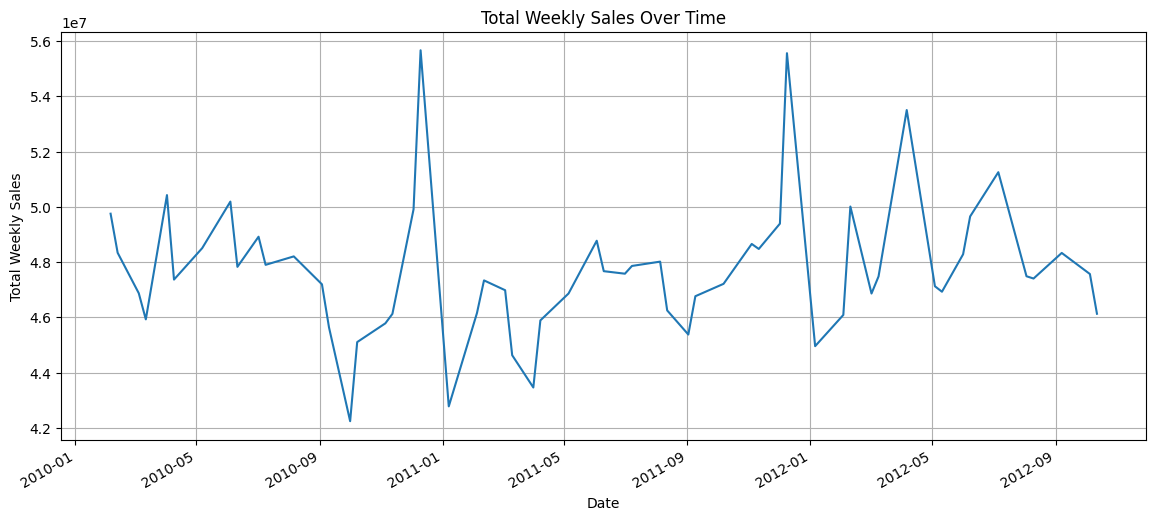

In [10]:
#Makes graph wider and readable.
plt.figure(figsize=(14,6))

#Groups all stores together by week and sums total sales.
df.groupby('Date')['Weekly_Sales'].sum().plot()

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.grid(True)

plt.show()

In [11]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

store_sales.head()

Store
20    1.236541e+08
4     1.190478e+08
14    1.182858e+08
13    1.138956e+08
2     1.112614e+08
Name: Weekly_Sales, dtype: float64

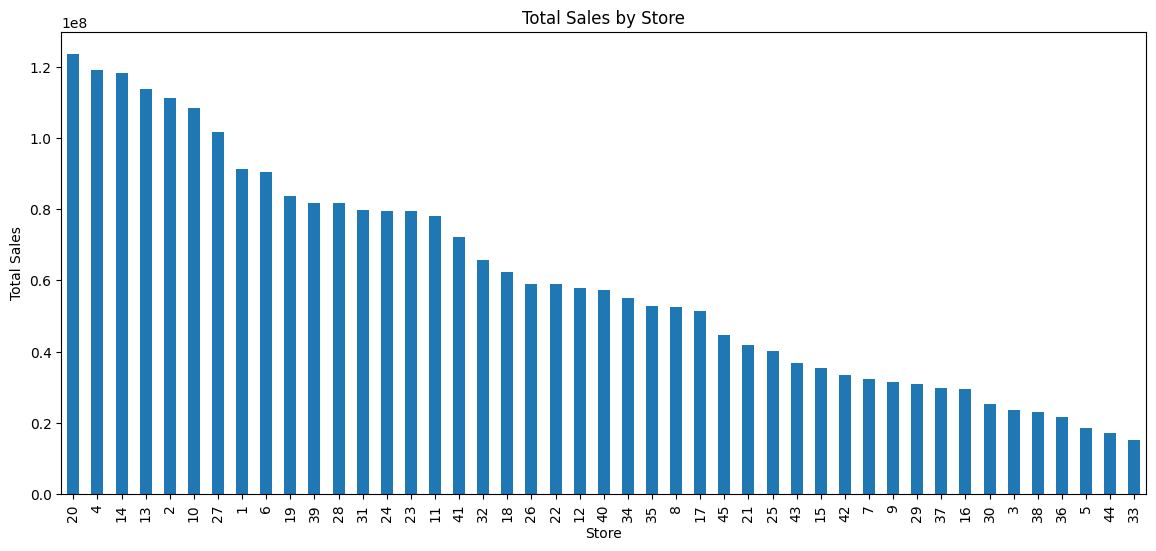

In [12]:
plt.figure(figsize=(14,6))
store_sales.plot(kind='bar')
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

In [14]:
store_std = df.groupby('Store')['Weekly_Sales'].std().sort_values(ascending=False)

store_std.head()

Store
14    224425.651713
27    180950.058463
10    178732.213234
20    167719.243678
35    165835.457210
Name: Weekly_Sales, dtype: float64

In [16]:
# Create and write to a text file
with open("analysis_output.txt", "w") as file:
    file.write("Walmart Sales Analysis\n")
    file.write("========================\n")
    file.write("Store 20 has the highest total sales.\n")
    file.write("Store 14 has the highest sales variability.\n")
    file.write("Holiday sales are higher than non-holiday sales.\n")

print("Text file created successfully")

Text file created successfully


In [18]:
holiday_avg = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

holiday_avg

non_holiday = holiday_avg[0]
holiday = holiday_avg[1]

percentage_increase = ((holiday - non_holiday) / non_holiday) * 100

print("Percentage Increase in Sales During Holidays:", percentage_increase, "%")


Percentage Increase in Sales During Holidays: 0.09551547416855634 %


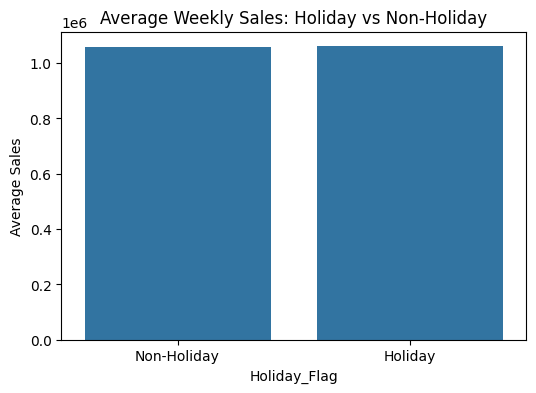

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x=holiday_avg.index, y=holiday_avg.values)

plt.xticks([0,1], ['Non-Holiday', 'Holiday'])
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Sales")

plt.show()

In [20]:
#Which store has good quarterly growth rate in Q3 2012?
# Q2 2012 (April–June)
q2_2012 = df[(df['Year'] == 2012) & 
             (df['Month'].isin([4,5,6]))]

q2_sales = q2_2012.groupby('Store')['Weekly_Sales'].sum()

# Q3 2012 (July–September)
q3_2012 = df[(df['Year'] == 2012) & 
             (df['Month'].isin([7,8,9]))]

q3_sales = q3_2012.groupby('Store')['Weekly_Sales'].sum()

# Combine into DataFrame
growth_df = pd.DataFrame({
    'Q2_Sales': q2_sales,
    'Q3_Sales': q3_sales
})

# Calculate Growth %
growth_df['Growth_%'] = ((growth_df['Q3_Sales'] - growth_df['Q2_Sales']) 
                           / growth_df['Q2_Sales']) * 100

# Sort by highest growth
growth_df = growth_df.sort_values(by='Growth_%', ascending=False)

growth_df.head()

,Q2_Sales,Q3_Sales,Growth_%
Store,,,
7,2788481.05,2760400.27,-1.007028
16,2545407.51,2316939.66,-8.975689
35,4240324.22,3724898.15,-12.155346
24,7060713.11,6059661.44,-14.177770
26,5247981.11,4474736.43,-14.734136


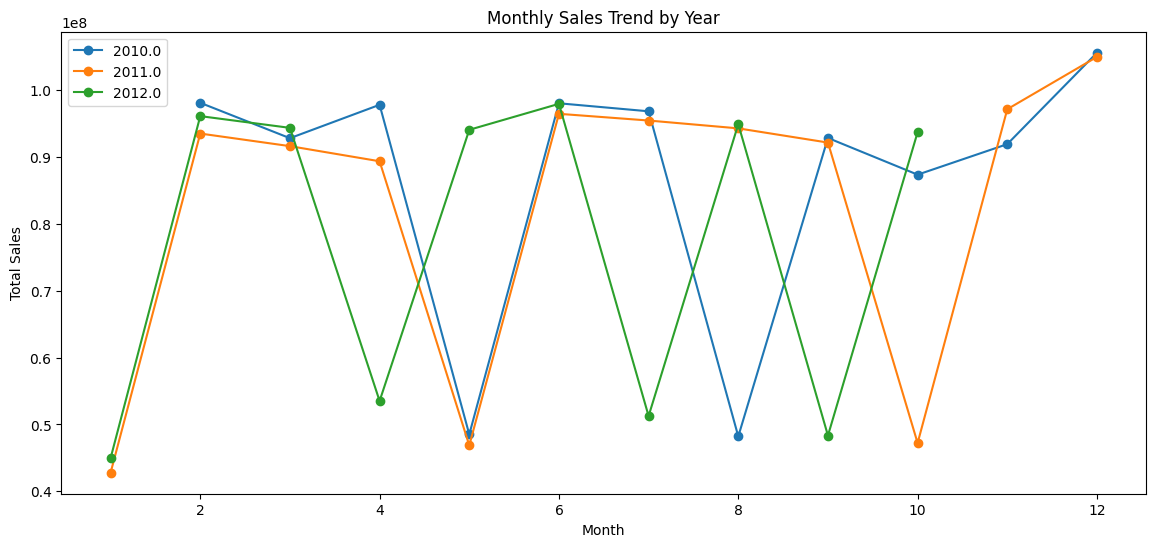

In [21]:
monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14,6))

for year in monthly_sales['Year'].unique():
    subset = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(subset['Month'], subset['Weekly_Sales'], marker='o', label=year)

plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

In [22]:
# Create Semester column
df['Semester'] = df['Month'].apply(lambda x: 'H1' if x <= 6 else 'H2')

semester_sales = df.groupby(['Year', 'Semester'])['Weekly_Sales'].sum().reset_index()

semester_sales

,Year,Semester,Weekly_Sales
0,2010.0,H1,4.351917e+08
1,2010.0,H2,5.226761e+08
2,2011.0,H1,4.605232e+08
3,2011.0,H2,5.311358e+08
4,2012.0,H1,4.808771e+08
5,2012.0,H2,2.881676e+08


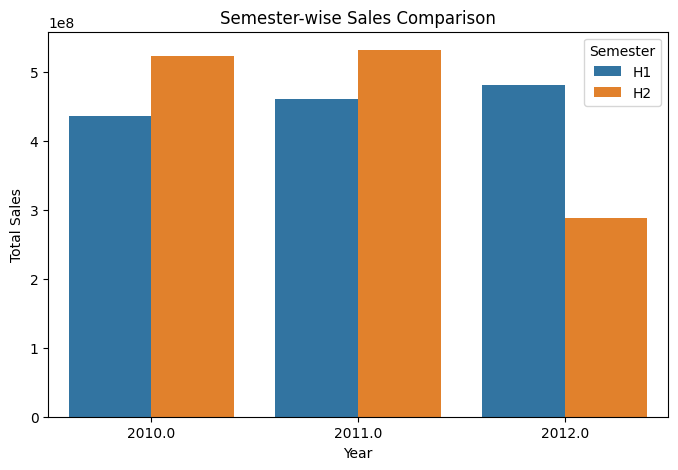

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(data=semester_sales, x='Year', y='Weekly_Sales', hue='Semester')

plt.title("Semester-wise Sales Comparison")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
#Filter Store 1
store1 = df[df['Store'] == 1]

store1.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Semester
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010.0,2.0,5,H1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010.0,2.0,6,H1
2,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010.0,3.0,9,H1
3,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010.0,3.0,10,H1
4,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010.0,4.0,13,H1


In [ ]:
#Select Features & Target
X = store1[['Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']]
y = store1['Weekly_Sales']

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
#Predictions & Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 53959.29017460622
RMSE: 68545.27542548241
R2 Score: 0.23420738308065303


In [30]:
X = store1[['Fuel_Price', 'CPI', 'Unemployment', 
            'Holiday_Flag', 'Month', 'Year', 'Week']]
y = store1['Weekly_Sales']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 46471.19202960073
RMSE: 67819.21392541389
R2 Score: 0.25034468120704234
